# Sistem Multi-Agent pentru Compararea Modelelor de Machine Learning

## Descriere proiect

Acest proiect implementează un sistem multi-agent pentru analiza și clasificarea datelor utilizând mai multe modele de Machine Learning din biblioteca scikit-learn.

Sistemul este împărțit în mai mulți agenți independenți, fiecare având un rol specific în fluxul de procesare al datelor:

- Agentul 1 – încărcarea și analiza datasetului
- Agentul 2 – preprocesarea datelor și pregătirea acestora pentru modelele de clasificare
- Agentul 3 – antrenarea, evaluarea și compararea mai multor modele de Machine Learning
- Agentul 4 - vizualizare și analiză rezultate (grafice)

În cadrul proiectului sunt comparate următoarele modele:
- Decision Tree
- K-Nearest Neighbors (KNN)
- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest
- Neural Network (MLPClassifier)

Sistemul decide automat ce modele necesită standardizarea datelor înainte de antrenare.

Datasetul utilizat este Titanic Dataset din biblioteca seaborn.

Scopul proiectului este identificarea modelului cu cea mai bună performanță pe același set de date, utilizând metrici de clasificare precum Accuracy, Precision, Recall și F1 Score.

În plus, proiectul analizează diferența dintre performanța pe setul de antrenare și performanța pe setul de testare, pentru a identifica posibile situații de overfitting.

## Agent 1 – DataLoaderAgent

Acest agent este responsabil cu încărcarea și analiza preliminară a datasetului utilizat în proiect.

Funcționalitățile agentului:
- încarcă Titanic Dataset din biblioteca seaborn;
- transformă datele într-un DataFrame Pandas;
- separă caracteristicile (features) și variabila țintă (target);
- afișează dimensiunea datasetului;
- afișează primele instanțe din setul de date;
- afișează numele atributelor și clasele problemei;
- verifică existența valorilor lipsă;
- afișează distribuția claselor;
- calculează statistici descriptive pentru fiecare atribut.

Datele analizate de acest agent sunt transmise către Agentul 2 pentru etapa de preprocesare.

In [1]:
import pandas as pd
import seaborn as sns

class DataLoaderAgent:
    def __init__(self):
        self.data = None
        self.X = None
        self.y = None

    def load_dataset(self):
        self.data = sns.load_dataset("titanic")

        print("Dataset Titanic încărcat cu succes!")

        self.y = self.data["survived"]
        self.X = self.data.drop(columns=["survived"])

        return self.data

    def show_basic_info(self):
        print("Dimensiunea datasetului:")
        print(self.data.shape)

        print("\nPrimele 5 rânduri:")
        display(self.data.head())

        print("\nNumele atributelor:")
        print(list(self.X.columns))

        print("\nClasele problemei:")
        print(sorted(self.y.unique()))

        print("\nDistribuția claselor:")
        display(self.y.value_counts())

        print("\nValori lipsă pe fiecare coloană:")
        display(self.data.isnull().sum())

        print("\nProcent valori lipsă pe fiecare coloană:")
        missing_percent = (self.data.isnull().sum() / len(self.data)) * 100
        display(missing_percent.sort_values(ascending=False))

        print("\nTipurile de date:")
        display(self.data.dtypes)

        print("\nStatistici descriptive pentru atributele numerice:")
        display(self.data.describe())

        print("\nStatistici descriptive pentru atributele categorice:")
        categorical_data = self.data.select_dtypes(include=["object", "category", "bool"])

        if categorical_data.shape[1] > 0:
            display(categorical_data.describe())
        else:
            print("Nu există atribute categorice.")

    def get_features_and_target(self):
        return self.X, self.y


In [2]:
agent1 = DataLoaderAgent()

data = agent1.load_dataset()
agent1.show_basic_info()

X, y = agent1.get_features_and_target()

Dataset Titanic încărcat cu succes!
Dimensiunea datasetului:
(891, 15)

Primele 5 rânduri:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Numele atributelor:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Clasele problemei:
[np.int64(0), np.int64(1)]

Distribuția claselor:


survived
0    549
1    342
Name: count, dtype: int64


Valori lipsă pe fiecare coloană:


...


Statistici descriptive pentru atributele numerice:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Statistici descriptive pentru atributele categorice:


C:\Users\Deea\AppData\Local\Temp\ipykernel_35420\3629184296.py:50: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_data = self.data.select_dtypes(include=["object", "category", "bool"])


,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891,889,891,891,891,203,889,891,891
unique,2,3,3,3,2,7,3,2,2
top,male,S,Third,man,True,C,Southampton,no,True
freq,577,644,491,537,537,59,644,549,537


## Agent 2 – PreprocessingAgent

Acest agent este responsabil cu etapa de preprocesare a datelor înainte de antrenarea modelelor de Machine Learning.

Funcționalitățile agentului:
- verifică existența valorilor lipsă;
- elimină coloanele nerelevante sau cu prea multe valori lipsă;
- completează automat valorile lipsă rămase folosind media pentru atributele numerice și moda pentru atributele categorice;
- rotunjește valorile completate pentru atributul age pentru a păstra consistența datasetului;
- transformă variabilele categorice în variabile numerice folosind one-hot encoding;
- transformă valorile booleene în valori numerice;
- verifică dacă toate datele sunt numerice înainte de etapa de antrenare;
- împarte datele în seturi de train și test;
- generează mai multe variante ale aceluiași dataset:
  - Original
  - Standardized
  - MinMax Scaled
  - Normalized
  - Robust Scaled

Scopul acestui agent este analiza impactului diferitelor tehnici de preprocesare asupra performanței modelelor de clasificare.

Datele preprocesate sunt transmise către Agentul 3 pentru etapa de antrenare și evaluare a modelelor.

In [3]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer, RobustScaler


class PreprocessingAgent:
    def __init__(self, test_size=0.2, random_state=42):
        self.test_size = test_size
        self.random_state = random_state

        self.columns_to_drop = [
            "alive",
            "class",
            "who",
            "adult_male",
            "embark_town",
            "deck"
        ]

    def drop_unnecessary_columns(self, X):
        existing_columns_to_drop = [
            column for column in self.columns_to_drop
            if column in X.columns
        ]

        if len(existing_columns_to_drop) > 0:
            print("Coloane eliminate:")
            for column in existing_columns_to_drop:
                print("-", column)

            X = X.drop(columns=existing_columns_to_drop)
        else:
            print("Nu există coloane de eliminat.")

        return X

    def handle_missing_values(self, X):
        missing_values = X.isnull().sum().sum()

        if missing_values > 0:
            print(f"Există {missing_values} valori lipsă.")
            print("Valorile lipsă vor fi completate cu media/moda coloanelor.")

            for column in X.columns:
                if X[column].isnull().sum() > 0:

                    if pd.api.types.is_numeric_dtype(X[column]):
                        fill_value = X[column].mean()

                        if column == "age":
                            fill_value = round(fill_value)

                        X[column] = X[column].fillna(fill_value)
                        print(f"- {column}: completat cu media {fill_value}")

                    else:
                        fill_value = X[column].mode()[0]
                        X[column] = X[column].fillna(fill_value)
                        print(f"- {column}: completat cu moda '{fill_value}'")
        else:
            print("Nu există valori lipsă.")

        return X

    def encode_categorical_variables(self, X):
        categorical_columns = []

        for column in X.columns:
            if not pd.api.types.is_numeric_dtype(X[column]):
                categorical_columns.append(column)

        if len(categorical_columns) > 0:
            print("Variabile categorice transformate în variabile numerice:")
            for column in categorical_columns:
                print("-", column)

            X = pd.get_dummies(
                X,
                columns=categorical_columns,
                drop_first=True,
                dtype=int
            )
        else:
            print("Nu există variabile categorice de transformat.")

        return X

    def convert_bool_columns_to_int(self, X):
        bool_columns = []

        for column in X.columns:
            if X[column].dtype == "bool":
                bool_columns.append(column)

        if len(bool_columns) > 0:
            for column in bool_columns:
                X[column] = X[column].astype(int)

        return X

    def check_final_data(self, X):
        non_numeric_columns = []

        for column in X.columns:
            if not pd.api.types.is_numeric_dtype(X[column]):
                non_numeric_columns.append(column)

        if len(non_numeric_columns) > 0:
            print("Atenție! Au rămas coloane nenumerice:")
            print(non_numeric_columns)
            print(X[non_numeric_columns].head())
            raise ValueError("Există încă valori text în dataset. Verifică encoding-ul.")

        print("Verificare finală: toate coloanele sunt numerice.")
        return X

    def split_data(self, X, y):
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=y
        )

        print("Datele au fost împărțite în train și test.")
        print("X_train:", X_train.shape)
        print("X_test:", X_test.shape)
        print("y_train:", y_train.shape)
        print("y_test:", y_test.shape)

        return X_train, X_test, y_train, y_test

    def create_dataset_versions(self, X_train, X_test, y_train, y_test):
        dataset_versions = {}

        dataset_versions["Original"] = {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test
        }

        standard_scaler = StandardScaler()
        dataset_versions["Standardized"] = {
            "X_train": standard_scaler.fit_transform(X_train),
            "X_test": standard_scaler.transform(X_test),
            "y_train": y_train,
            "y_test": y_test
        }

        minmax_scaler = MinMaxScaler()
        dataset_versions["MinMax Scaled"] = {
            "X_train": minmax_scaler.fit_transform(X_train),
            "X_test": minmax_scaler.transform(X_test),
            "y_train": y_train,
            "y_test": y_test
        }

        normalizer = Normalizer()
        dataset_versions["Normalized"] = {
            "X_train": normalizer.fit_transform(X_train),
            "X_test": normalizer.transform(X_test),
            "y_train": y_train,
            "y_test": y_test
        }

        robust_scaler = RobustScaler()
        dataset_versions["Robust Scaled"] = {
            "X_train": robust_scaler.fit_transform(X_train),
            "X_test": robust_scaler.transform(X_test),
            "y_train": y_train,
            "y_test": y_test
        }

        return dataset_versions

    def prepare_dataset_versions(self, X, y):
        X = X.copy()
        y = y.copy()

        X = self.drop_unnecessary_columns(X)
        X = self.handle_missing_values(X)
        X = self.encode_categorical_variables(X)
        X = self.convert_bool_columns_to_int(X)
        X = self.check_final_data(X)

        X_train, X_test, y_train, y_test = self.split_data(X, y)

        dataset_versions = self.create_dataset_versions(
            X_train,
            X_test,
            y_train,
            y_test
        )

        print("\nPreprocesarea a fost finalizată.")
        print("Au fost create variantele datasetului:")

        for dataset_name in dataset_versions.keys():
            print("-", dataset_name)

        return dataset_versions


Observație: X_train și X_test sunt matrici bidimensionale deoarece conțin mai multe caracteristici despre pasageri, precum clasa biletului, vârsta, sexul, tariful și portul de îmbarcare.

y_train și y_test sunt vectori unidimensionali deoarece conțin variabila țintă a problemei de clasificare, respectiv informația despre supraviețuirea pasagerilor.

In [4]:
agent2 = PreprocessingAgent()

dataset_versions = agent2.prepare_dataset_versions(X, y)

Coloane eliminate:
- alive
- class
- who
- adult_male
- embark_town
- deck
Există 179 valori lipsă.
Valorile lipsă vor fi completate cu media/moda coloanelor.
- age: completat cu media 30
- embarked: completat cu moda 'S'
Variabile categorice transformate în variabile numerice:
- sex
- embarked
Verificare finală: toate coloanele sunt numerice.
Datele au fost împărțite în train și test.
X_train: (712, 9)
X_test: (179, 9)
y_train: (712,)
y_test: (179,)

Preprocesarea a fost finalizată.
Au fost create variantele datasetului:
- Original
- Standardized
- MinMax Scaled
- Normalized
- Robust Scaled


In [5]:
for dataset_name, data in dataset_versions.items():
    X_train = data["X_train"]
    X_test = data["X_test"]

    train_missing = pd.DataFrame(X_train).isnull().sum().sum()
    test_missing = pd.DataFrame(X_test).isnull().sum().sum()

    print("="*50)
    print(f"Dataset: {dataset_name}")
    print(f"Valori lipsă în X_train: {train_missing}")
    print(f"Valori lipsă în X_test: {test_missing}")

Dataset: Original
Valori lipsă în X_train: 0
Valori lipsă în X_test: 0
Dataset: Standardized
Valori lipsă în X_train: 0
Valori lipsă în X_test: 0
Dataset: MinMax Scaled
Valori lipsă în X_train: 0
Valori lipsă în X_test: 0
Dataset: Normalized
Valori lipsă în X_train: 0
Valori lipsă în X_test: 0
Dataset: Robust Scaled
Valori lipsă în X_train: 0
Valori lipsă în X_test: 0


In [6]:
print("Rânduri cu valori lipsă ÎNAINTE:")

missing_rows_index = X[X.isnull().any(axis=1)].head().index
display(X.loc[missing_rows_index])

X_filled = X.copy()

for column in X_filled.columns:

    if X_filled[column].isnull().sum() > 0:

        if pd.api.types.is_numeric_dtype(X_filled[column]):

            fill_value = X_filled[column].mean()

            if column == "age":
                fill_value = round(fill_value)

            X_filled[column] = X_filled[column].fillna(fill_value)

        else:
            fill_value = X_filled[column].mode()[0]
            X_filled[column] = X_filled[column].fillna(fill_value)

print("\nRânduri DUPĂ completarea valorilor lipsă:")
display(X_filled.loc[missing_rows_index])

Rânduri cu valori lipsă ÎNAINTE:


,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
2,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
4,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
7,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False



Rânduri DUPĂ completarea valorilor lipsă:


,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,3,male,22.0,1,0,7.2500,S,Third,man,True,C,Southampton,no,False
2,3,female,26.0,0,0,7.9250,S,Third,woman,False,C,Southampton,yes,True
4,3,male,35.0,0,0,8.0500,S,Third,man,True,C,Southampton,no,True
5,3,male,30.0,0,0,8.4583,Q,Third,man,True,C,Queenstown,no,True
7,3,male,2.0,3,1,21.0750,S,Third,child,False,C,Southampton,no,False


## Agent 3 – ModelTrainerAgent

Acest agent este responsabil cu antrenarea, optimizarea și evaluarea modelelor de Machine Learning.

Funcționalitățile agentului:
- primește datele preprocesate de la Agentul 2;
- antrenează mai multe modele de clasificare:
  - Decision Tree
  - KNN
  - Logistic Regression
  - SVM
  - Random Forest
  - MLP Neural Network;
- testează fiecare model pe toate variantele datasetului:
  - Original
  - Standardized
  - MinMax Scaled
  - Normalized
  - Robust Scaled;
- utilizează GridSearchCV pentru găsirea automată a celor mai buni parametri pentru fiecare model;
- evaluează performanța modelelor folosind:
  - Accuracy
  - Precision
  - Recall
  - F1-Score;
- calculează performanța atât pe datele de antrenare, cât și pe datele de test;
- detectează posibile probleme de overfitting prin compararea performanței pe datele de antrenare și test;
- oferă recomandări privind capacitatea de generalizare a modelelor;
- afișează matricea de confuzie și classification report pentru fiecare model;
- compară performanțele tuturor combinațiilor model + dataset;
- selectează automat cea mai bună combinație model + dataset pe baza performanțelor obținute.

La final, rezultatele obținute sunt transmise către Agentul 4 pentru vizualizare și analiză grafică.

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pandas as pd


class ModelTrainerAgent:
    def __init__(self):
        self.models = {
            "Decision Tree": DecisionTreeClassifier(random_state=42),
            "KNN": KNeighborsClassifier(),
            "Logistic Regression": LogisticRegression(max_iter=10000, random_state=42),
            "SVM": SVC(random_state=42),
            "Random Forest": RandomForestClassifier(random_state=42),
            "MLP Neural Network": MLPClassifier(max_iter=2000, random_state=42)
        }

        self.param_grids = {
            "Decision Tree": {
                "max_depth": [3, 5, 7, None],
                "criterion": ["gini", "entropy"]
            },

            "KNN": {
                "n_neighbors": [3, 5, 7, 9],
                "weights": ["uniform", "distance"]
            },

            "Logistic Regression": {
                "C": [0.01, 0.1, 1, 10],
                "solver": ["liblinear", "lbfgs"]
            },

            "SVM": {
                "C": [0.1, 1, 10],
                "kernel": ["linear", "rbf"],
                "gamma": ["scale", "auto"]
            },

            "Random Forest": {
                "n_estimators": [50, 100, 150],
                "max_depth": [5, 10, None],
                "criterion": ["gini", "entropy"]
            },

            "MLP Neural Network": {
                "hidden_layer_sizes": [(50,), (100,), (100, 50)],
                "learning_rate_init": [0.001, 0.01],
                "activation": ["relu", "tanh"]
            }
        }

        self.results = []
        self.best_models = {}

    def analyze_overfitting(self, train_accuracy, test_accuracy):
        difference = train_accuracy - test_accuracy

        if difference > 0.10:
            status = "Overfitting ridicat"
            recommendation = "Modelul învață prea bine datele de antrenare. Se recomandă reducerea complexității."
        elif difference > 0.05:
            status = "Posibil overfitting"
            recommendation = "Modelul poate fi ușor supraantrenat. Se recomandă verificarea parametrilor."
        else:
            status = "Generalizare bună"
            recommendation = "Modelul generalizează bine pe datele de test."

        return difference, status, recommendation

    def train_and_evaluate(self, dataset_versions):
        self.results = []
        self.best_models = {}

        for dataset_name, data in dataset_versions.items():

            print("\n" + "#" * 60)
            print(f"DATASET: {dataset_name}")
            print("#" * 60)

            X_train = data["X_train"]
            X_test = data["X_test"]
            y_train = data["y_train"]
            y_test = data["y_test"]

            for model_name, model in self.models.items():

                print("\n" + "=" * 50)
                print(f"Model: {model_name}")
                print("=" * 50)

                grid_search = GridSearchCV(
                    estimator=model,
                    param_grid=self.param_grids[model_name],
                    cv=5,
                    scoring="accuracy",
                    n_jobs=-1
                )

                grid_search.fit(X_train, y_train)

                best_model = grid_search.best_estimator_
                self.best_models[(dataset_name, model_name)] = best_model

                print("Cei mai buni parametri:")
                print(grid_search.best_params_)

                y_train_pred = best_model.predict(X_train)
                y_test_pred = best_model.predict(X_test)

                train_accuracy = accuracy_score(y_train, y_train_pred)
                test_accuracy = accuracy_score(y_test, y_test_pred)

                precision = precision_score(y_test, y_test_pred, zero_division=0)
                recall = recall_score(y_test, y_test_pred, zero_division=0)
                f1 = f1_score(y_test, y_test_pred, zero_division=0)

                overfit_difference, overfit_status, recommendation = self.analyze_overfitting(
                    train_accuracy,
                    test_accuracy
                )

                print(f"Train Accuracy: {train_accuracy:.4f}")
                print(f"Test Accuracy: {test_accuracy:.4f}")
                print(f"Precision: {precision:.4f}")
                print(f"Recall: {recall:.4f}")
                print(f"F1 Score: {f1:.4f}")

                print(f"Overfitting Difference: {overfit_difference:.4f}")
                print(f"Status: {overfit_status}")
                print(f"Recomandare: {recommendation}")

                print("\nConfusion Matrix:")
                print(confusion_matrix(y_test, y_test_pred))

                print("\nClassification Report:")
                print(classification_report(y_test, y_test_pred, zero_division=0))

                self.results.append({
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Accuracy": test_accuracy,
                    "Precision": precision,
                    "Recall": recall,
                    "F1 Score": f1,
                    "Train Accuracy": train_accuracy,
                    "Test Accuracy": test_accuracy,
                    "Overfitting Difference": overfit_difference,
                    "Overfitting Status": overfit_status,
                    "Recommendation": recommendation,
                    "Best Parameters": grid_search.best_params_
                })

    def show_final_results(self):
        results_df = pd.DataFrame(self.results)

        results_df = results_df.sort_values(
            by=["Test Accuracy", "F1 Score", "Overfitting Difference"],
            ascending=[False, False, True]
        )

        print("\n================ REZULTATE FINALE ================\n")
        display(results_df)

        best_model = results_df.iloc[0]

        print("\nCel mai bun model final este:")
        print(f"Dataset: {best_model['Dataset']}")
        print(f"Model: {best_model['Model']}")

        print("\nCei mai buni parametri:")
        print(best_model["Best Parameters"])

        print(f"\nTrain Accuracy: {best_model['Train Accuracy']:.4f}")
        print(f"Test Accuracy: {best_model['Test Accuracy']:.4f}")
        print(f"F1 Score: {best_model['F1 Score']:.4f}")

        print("\nAnaliză overfitting:")
        print(best_model["Overfitting Status"])
        print(best_model["Recommendation"])

        return results_df

In [8]:
agent3 = ModelTrainerAgent()

agent3.train_and_evaluate(dataset_versions)

results_df = agent3.show_final_results()


############################################################
DATASET: Original
############################################################

Model: Decision Tree
Cei mai buni parametri:
{'criterion': 'gini', 'max_depth': 5}
Train Accuracy: 0.8652
Test Accuracy: 0.7765
Precision: 0.7544
Recall: 0.6232
F1 Score: 0.6825
Overfitting Difference: 0.0886
Status: Posibil overfitting
Recomandare: Modelul poate fi ușor supraantrenat. Se recomandă verificarea parametrilor.

Confusion Matrix:
[[96 14]
 [26 43]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       110
           1       0.75      0.62      0.68        69

    accuracy                           0.78       179
   macro avg       0.77      0.75      0.76       179
weighted avg       0.77      0.78      0.77       179


Model: KNN
Cei mai buni parametri:
{'n_neighbors': 9, 'weights': 'distance'}
Train Accuracy: 0.9831
Test Accuracy: 0.7207
Precision: 0.6462
Re

,Dataset,Model,Accuracy,Precision,Recall,F1 Score,Train Accuracy,Test Accuracy,Overfitting Difference,Overfitting Status,Recommendation,Best Parameters
22,Normalized,Random Forest,0.826816,0.816667,0.710145,0.759690,0.856742,0.826816,0.029926,Generalizare bună,Modelul generalizează bine pe datele de test.,"{'criterion': 'entropy', 'max_depth': 5, 'n_es..."
17,MinMax Scaled,MLP Neural Network,0.826816,0.865385,0.652174,0.743802,0.846910,0.826816,0.020094,Generalizare bună,Modelul generalizează bine pe datele de test.,"{'activation': 'relu', 'hidden_layer_sizes': (..."
7,Standardized,KNN,0.815642,0.790323,0.710145,0.748092,0.844101,0.815642,0.028459,Generalizare bună,Modelul generalizează bine pe datele de test.,"{'n_neighbors': 5, 'weights': 'uniform'}"
9,Standardized,SVM,0.815642,0.833333,0.652174,0.731707,0.841292,0.815642,0.025650,Generalizare bună,Modelul generalizează bine pe datele de test.,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}"
8,Standardized,Logistic Regression,0.815642,0.846154,0.637681,0.727273,0.810393,0.815642,-0.005249,Generalizare bună,Modelul generalizează bine pe datele de test.,"{'C': 0.01, 'solver': 'lbfgs'}"
15,MinMax Scaled,SVM,0.815642,0.875000,0.608696,0.717949,0.841292,0.815642,0.025650,Generalizare bună,Modelul generalizează bine pe datele de test.,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}"
13,MinMax Scaled,KNN,0.810056,0.786885,0.695652,0.738462,0.873596,0.810056,0.063540,Posibil overfitting,Modelul poate fi ușor supraantrenat. Se recoma...,"{'n_neighbors': 3, 'weights': 'uniform'}"
27,Robust Scaled,SVM,0.810056,0.818182,0.652174,0.725806,0.860955,0.810056,0.050899,Posibil overfitting,Modelul poate fi ușor supraantrenat. Se recoma...,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}"
4,Original,Random Forest,0.810056,0.872340,0.594203,0.706897,0.852528,0.810056,0.042472,Generalizare bună,Modelul generalizează bine pe datele de test.,"{'criterion': 'entropy', 'max_depth': 5, 'n_es..."
10,Standardized,Random Forest,0.810056,0.872340,0.594203,0.706897,0.852528,0.810056,0.042472,Generalizare bună,Modelul generalizează bine pe datele de test.,"{'criterion': 'entropy', 'max_depth': 5, 'n_es..."



Cel mai bun model final este:
Dataset: Normalized
Model: Random Forest

Cei mai buni parametri:
{'criterion': 'entropy', 'max_depth': 5, 'n_estimators': 50}

Train Accuracy: 0.8567
Test Accuracy: 0.8268
F1 Score: 0.7597

Analiză overfitting:
Generalizare bună
Modelul generalizează bine pe datele de test.


## Agent 4 – VisualizationAgent

Acest agent este responsabil cu vizualizarea, compararea și interpretarea finală a rezultatelor obținute de Agentul 3.

Funcționalitățile agentului:
- primește rezultatele finale ale modelelor antrenate;
- afișează tabelul complet cu toate combinațiile model + dataset;
- afișează topul celor mai bune combinații pe baza performanțelor obținute;
- evidențiază automat cel mai bun model final;
- afișează cei mai buni parametri ai modelului câștigător;
- construiește grafice comparative pentru:
  - Test Accuracy;
  - F1-Score;
  - Accuracy vs F1-Score;
  - Train Accuracy vs Test Accuracy;
  - diferența de overfitting;
- construiește heatmap-uri pentru:
  - Test Accuracy;
  - F1-Score;
- compară:
  - fiecare model pe toate variantele datasetului;
  - toate modelele pe fiecare variantă de dataset;
- afișează matricea de confuzie pentru cel mai bun model;
- identifică automat:
  - cel mai bun model pentru fiecare dataset;
  - cel mai bun dataset pentru fiecare model;
- generează insight-uri automate privind:
  - performanța modelelor;
  - influența tehnicilor de preprocesare;
  - posibile probleme de overfitting.

Acest agent facilitează interpretarea vizuală a rezultatelor și susține alegerea finală a celei mai bune combinații model + dataset.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay


class VisualizationAgent:

    def __init__(self, results, best_models=None, dataset_versions=None):
        self.results_df = pd.DataFrame(results)
        self.best_models = best_models
        self.dataset_versions = dataset_versions

        self.results_df = self.results_df.sort_values(
            by=["Test Accuracy", "F1 Score", "Overfitting Difference"],
            ascending=[False, False, True]
        ).reset_index(drop=True)

    def show_results_table(self):
        print("\n================ TABEL COMPLET REZULTATE ================\n")
        display(self.results_df)

    def show_top_results(self, top_n=10):
        print(f"\n================ TOP {top_n} COMBINAȚII ================\n")
    
        columns = [
            "Dataset",
            "Model",
            "Test Accuracy",
            "F1 Score",
            "Precision",
            "Recall",
            "Overfitting Difference",
            "Overfitting Status",
            "Best Parameters"
        ]
    
        status_priority = {
            "Generalizare bună": 0,
            "Posibil overfitting": 1,
            "Overfitting ridicat": 2
        }
    
        df_top = self.results_df.copy()
    
        df_top["Overfitting Priority"] = df_top["Overfitting Status"].map(status_priority)
    
        df_top = df_top.sort_values(
            by=[
                "Test Accuracy",
                "Overfitting Priority",
                "F1 Score",
                "Overfitting Difference"
            ],
            ascending=[
                False,
                True,
                False,
                True
            ]
        )
    
        display(df_top[columns].head(top_n))

    def show_best_model(self):
        best_model = self.results_df.iloc[0]

        print("\n================ CEL MAI BUN MODEL FINAL ================\n")
        print("Dataset:", best_model["Dataset"])
        print("Model:", best_model["Model"])
        print("Test Accuracy:", round(best_model["Test Accuracy"], 4))
        print("F1 Score:", round(best_model["F1 Score"], 4))
        print("Precision:", round(best_model["Precision"], 4))
        print("Recall:", round(best_model["Recall"], 4))
        print("Overfitting Difference:", round(best_model["Overfitting Difference"], 4))
        print("Status:", best_model["Overfitting Status"])

        print("\nCei mai buni parametri:")
        print(best_model["Best Parameters"])

    def plot_accuracy_all_combinations(self):
        df = self.results_df.copy()
        df["Combination"] = df["Model"] + " | " + df["Dataset"]

        plt.figure(figsize=(14, 7))
        plt.bar(df["Combination"], df["Test Accuracy"])

        plt.title("Compararea tuturor combinațiilor Model + Dataset după Test Accuracy")
        plt.xlabel("Model + Tip dataset")
        plt.ylabel("Test Accuracy")
        plt.xticks(rotation=90)
        plt.ylim(0, 1)
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    def plot_f1_all_combinations(self):
        df = self.results_df.copy()

        df = df.sort_values(
            by="F1 Score",
            ascending=False
        )
        
        df["Combination"] = df["Model"] + " | " + df["Dataset"]

        plt.figure(figsize=(14, 7))
        plt.bar(df["Combination"], df["F1 Score"])

        plt.title("Compararea tuturor combinațiilor Model + Dataset după F1 Score")
        plt.xlabel("Model + Tip dataset")
        plt.ylabel("F1 Score")
        plt.xticks(rotation=90)
        plt.ylim(0, 1)
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    def plot_accuracy_heatmap(self):
        pivot = self.results_df.pivot(
            index="Model",
            columns="Dataset",
            values="Test Accuracy"
        )

        plt.figure(figsize=(10, 6))
        plt.imshow(pivot, aspect="auto")

        plt.title("Heatmap - Test Accuracy pentru fiecare Model și Dataset")
        plt.xlabel("Tip dataset")
        plt.ylabel("Model")

        plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
        plt.yticks(range(len(pivot.index)), pivot.index)

        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                value = pivot.iloc[i, j]
                plt.text(j, i, f"{value:.3f}", ha="center", va="center")

        plt.colorbar(label="Test Accuracy")
        plt.tight_layout()
        plt.show()

    def plot_f1_heatmap(self):
        pivot = self.results_df.pivot(
            index="Model",
            columns="Dataset",
            values="F1 Score"
        )

        plt.figure(figsize=(10, 6))
        plt.imshow(pivot, aspect="auto")

        plt.title("Heatmap - F1 Score pentru fiecare Model și Dataset")
        plt.xlabel("Tip dataset")
        plt.ylabel("Model")

        plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
        plt.yticks(range(len(pivot.index)), pivot.index)

        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                value = pivot.iloc[i, j]
                plt.text(j, i, f"{value:.3f}", ha="center", va="center")

        plt.colorbar(label="F1 Score")
        plt.tight_layout()
        plt.show()

    def plot_each_model_across_datasets(self):
        models = self.results_df["Model"].unique()

        for model_name in models:
            df_model = self.results_df[self.results_df["Model"] == model_name]

            plt.figure(figsize=(9, 5))
            plt.bar(df_model["Dataset"], df_model["Test Accuracy"])

            plt.title(f"Performanța modelului {model_name} pe fiecare tip de dataset")
            plt.xlabel("Tip dataset")
            plt.ylabel("Test Accuracy")
            plt.ylim(0, 1)
            plt.xticks(rotation=45)
            plt.grid(axis="y", linestyle="--", alpha=0.5)
            plt.tight_layout()
            plt.show()

    def plot_each_dataset_across_models(self):
        datasets = self.results_df["Dataset"].unique()

        for dataset_name in datasets:
            df_dataset = self.results_df[self.results_df["Dataset"] == dataset_name]

            plt.figure(figsize=(10, 5))
            plt.bar(df_dataset["Model"], df_dataset["Test Accuracy"])

            plt.title(f"Compararea modelelor pe datasetul {dataset_name}")
            plt.xlabel("Model")
            plt.ylabel("Test Accuracy")
            plt.ylim(0, 1)
            plt.xticks(rotation=45)
            plt.grid(axis="y", linestyle="--", alpha=0.5)
            plt.tight_layout()
            plt.show()

    def plot_accuracy_vs_f1(self):
        df = self.results_df.copy()
        df["Combination"] = df["Model"] + " | " + df["Dataset"]

        x = range(len(df))

        plt.figure(figsize=(14, 6))

        plt.plot(x, df["Test Accuracy"], marker="o", label="Test Accuracy")
        plt.plot(x, df["F1 Score"], marker="o", label="F1 Score")

        plt.title("Comparație Test Accuracy vs F1 Score")
        plt.xlabel("Combinație Model + Dataset")
        plt.ylabel("Scor")
        plt.xticks(x, df["Combination"], rotation=90)
        plt.ylim(0, 1)
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_overfitting_difference(self):
        df = self.results_df.copy()
        df["Combination"] = df["Model"] + " | " + df["Dataset"]

        plt.figure(figsize=(14, 6))
        plt.bar(df["Combination"], df["Overfitting Difference"])

        plt.axhline(0.05, linestyle="--", label="Prag posibil overfitting")
        plt.axhline(0.10, linestyle="--", label="Prag overfitting ridicat")

        plt.title("Diferența Train Accuracy - Test Accuracy")
        plt.xlabel("Combinație Model + Dataset")
        plt.ylabel("Overfitting Difference")
        plt.xticks(rotation=90)
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_train_vs_test_accuracy(self):
        df = self.results_df.copy()
        df["Combination"] = df["Model"] + " | " + df["Dataset"]

        x = np.arange(len(df))
        width = 0.35

        plt.figure(figsize=(15, 6))
        plt.bar(x - width/2, df["Train Accuracy"], width, label="Train Accuracy")
        plt.bar(x + width/2, df["Test Accuracy"], width, label="Test Accuracy")

        plt.title("Train Accuracy vs Test Accuracy")
        plt.xlabel("Combinație Model + Dataset")
        plt.ylabel("Accuracy")
        plt.xticks(x, df["Combination"], rotation=90)
        plt.ylim(0, 1)
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_best_model_confusion_matrix(self):
        if self.best_models is None or self.dataset_versions is None:
            print("Nu există best_models sau dataset_versions.")
            return

        best_row = self.results_df.iloc[0]

        dataset_name = best_row["Dataset"]
        model_name = best_row["Model"]

        best_model = self.best_models[(dataset_name, model_name)]

        X_test = self.dataset_versions[dataset_name]["X_test"]
        y_test = self.dataset_versions[dataset_name]["y_test"]

        ConfusionMatrixDisplay.from_estimator(
            best_model,
            X_test,
            y_test
        )

        plt.title(f"Confusion Matrix - Best Model: {model_name} pe {dataset_name}")
        plt.tight_layout()
        plt.show()

    def show_best_model_for_each_dataset(self):
        print("\n================ CEL MAI BUN MODEL PENTRU FIECARE DATASET ================\n")

        best_per_dataset = self.results_df.sort_values(
            by=["Dataset", "Test Accuracy", "F1 Score"],
            ascending=[True, False, False]
        ).groupby("Dataset").head(1)

        display(best_per_dataset[
            ["Dataset", "Model", "Test Accuracy", "F1 Score", "Precision", "Recall", "Overfitting Status"]
        ])

    def show_best_dataset_for_each_model(self):
        print("\n================ CEL MAI BUN DATASET PENTRU FIECARE MODEL ================\n")

        best_per_model = self.results_df.sort_values(
            by=["Model", "Test Accuracy", "F1 Score"],
            ascending=[True, False, False]
        ).groupby("Model").head(1)

        display(best_per_model[
            ["Model", "Dataset", "Test Accuracy", "F1 Score", "Precision", "Recall", "Overfitting Status"]
        ])

    def generate_automatic_insights(self):
        print("\n================ INSIGHT-URI AUTOMATE ================\n")

        best_row = self.results_df.iloc[0]
        print(f"Cel mai bun rezultat general este obținut de modelul {best_row['Model']} pe datasetul {best_row['Dataset']}.")
        print(f"Accuracy: {best_row['Test Accuracy']:.4f}, F1 Score: {best_row['F1 Score']:.4f}")

        print("\nCel mai bun dataset pentru fiecare model:")
        best_per_model = self.results_df.sort_values(
            by=["Model", "Test Accuracy"],
            ascending=[True, False]
        ).groupby("Model").head(1)

        for _, row in best_per_model.iterrows():
            print(f"- {row['Model']}: cel mai bun pe {row['Dataset']} cu Accuracy = {row['Test Accuracy']:.4f}")

        print("\nCel mai bun model pentru fiecare variantă de dataset:")
        best_per_dataset = self.results_df.sort_values(
            by=["Dataset", "Test Accuracy"],
            ascending=[True, False]
        ).groupby("Dataset").head(1)

        for _, row in best_per_dataset.iterrows():
            print(f"- {row['Dataset']}: cel mai bun model este {row['Model']} cu Accuracy = {row['Test Accuracy']:.4f}")

        print("\nModele cu overfitting ridicat:")
        overfit_models = self.results_df[
            self.results_df["Overfitting Status"] == "Overfitting ridicat"
        ]

        if len(overfit_models) == 0:
            print("Nu există modele cu overfitting ridicat.")
        else:
            for _, row in overfit_models.iterrows():
                print(f"- {row['Model']} pe {row['Dataset']} are overfitting ridicat ({row['Overfitting Difference']:.4f}).")

    def run_all_visualizations(self):
        self.show_results_table()
        self.show_top_results(top_n=10)
        self.show_best_model()
        self.show_best_model_for_each_dataset()
        self.show_best_dataset_for_each_model()

        self.plot_accuracy_all_combinations()
        self.plot_f1_all_combinations()
        self.plot_accuracy_heatmap()
        self.plot_f1_heatmap()
        self.plot_accuracy_vs_f1()
        self.plot_train_vs_test_accuracy()
        self.plot_overfitting_difference()
        self.plot_each_model_across_datasets()
        self.plot_each_dataset_across_models()
        self.plot_best_model_confusion_matrix()

        self.generate_automatic_insights()


================ TABEL COMPLET REZULTATE ================



,Dataset,Model,Accuracy,Precision,Recall,F1 Score,Train Accuracy,Test Accuracy,Overfitting Difference,Overfitting Status,Recommendation,Best Parameters
0,Normalized,Random Forest,0.826816,0.816667,0.710145,0.759690,0.856742,0.826816,0.029926,Generalizare bună,Modelul generalizează bine pe datele de test.,"{'criterion': 'entropy', 'max_depth': 5, 'n_es..."
1,MinMax Scaled,MLP Neural Network,0.826816,0.865385,0.652174,0.743802,0.846910,0.826816,0.020094,Generalizare bună,Modelul generalizează bine pe datele de test.,"{'activation': 'relu', 'hidden_layer_sizes': (..."
2,Standardized,KNN,0.815642,0.790323,0.710145,0.748092,0.844101,0.815642,0.028459,Generalizare bună,Modelul generalizează bine pe datele de test.,"{'n_neighbors': 5, 'weights': 'uniform'}"
3,Standardized,SVM,0.815642,0.833333,0.652174,0.731707,0.841292,0.815642,0.025650,Generalizare bună,Modelul generalizează bine pe datele de test.,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}"
4,Standardized,Logistic Regression,0.815642,0.846154,0.637681,0.727273,0.810393,0.815642,-0.005249,Generalizare bună,Modelul generalizează bine pe datele de test.,"{'C': 0.01, 'solver': 'lbfgs'}"
5,MinMax Scaled,SVM,0.815642,0.875000,0.608696,0.717949,0.841292,0.815642,0.025650,Generalizare bună,Modelul generalizează bine pe datele de test.,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}"
6,MinMax Scaled,KNN,0.810056,0.786885,0.695652,0.738462,0.873596,0.810056,0.063540,Posibil overfitting,Modelul poate fi ușor supraantrenat. Se recoma...,"{'n_neighbors': 3, 'weights': 'uniform'}"
7,Robust Scaled,SVM,0.810056,0.818182,0.652174,0.725806,0.860955,0.810056,0.050899,Posibil overfitting,Modelul poate fi ușor supraantrenat. Se recoma...,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}"
8,Original,Random Forest,0.810056,0.872340,0.594203,0.706897,0.852528,0.810056,0.042472,Generalizare bună,Modelul generalizează bine pe datele de test.,"{'criterion': 'entropy', 'max_depth': 5, 'n_es..."
9,Standardized,Random Forest,0.810056,0.872340,0.594203,0.706897,0.852528,0.810056,0.042472,Generalizare bună,Modelul generalizează bine pe datele de test.,"{'criterion': 'entropy', 'max_depth': 5, 'n_es..."



================ TOP 10 COMBINAȚII ================



,Dataset,Model,Test Accuracy,F1 Score,Precision,Recall,Overfitting Difference,Overfitting Status,Best Parameters
0,Normalized,Random Forest,0.826816,0.759690,0.816667,0.710145,0.029926,Generalizare bună,"{'criterion': 'entropy', 'max_depth': 5, 'n_es..."
1,MinMax Scaled,MLP Neural Network,0.826816,0.743802,0.865385,0.652174,0.020094,Generalizare bună,"{'activation': 'relu', 'hidden_layer_sizes': (..."
2,Standardized,KNN,0.815642,0.748092,0.790323,0.710145,0.028459,Generalizare bună,"{'n_neighbors': 5, 'weights': 'uniform'}"
3,Standardized,SVM,0.815642,0.731707,0.833333,0.652174,0.025650,Generalizare bună,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}"
4,Standardized,Logistic Regression,0.815642,0.727273,0.846154,0.637681,-0.005249,Generalizare bună,"{'C': 0.01, 'solver': 'lbfgs'}"
5,MinMax Scaled,SVM,0.815642,0.717949,0.875000,0.608696,0.025650,Generalizare bună,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}"
8,Original,Random Forest,0.810056,0.706897,0.872340,0.594203,0.042472,Generalizare bună,"{'criterion': 'entropy', 'max_depth': 5, 'n_es..."
9,Standardized,Random Forest,0.810056,0.706897,0.872340,0.594203,0.042472,Generalizare bună,"{'criterion': 'entropy', 'max_depth': 5, 'n_es..."
10,MinMax Scaled,Random Forest,0.810056,0.706897,0.872340,0.594203,0.042472,Generalizare bună,"{'criterion': 'entropy', 'max_depth': 5, 'n_es..."
11,Robust Scaled,Random Forest,0.810056,0.706897,0.872340,0.594203,0.042472,Generalizare bună,"{'criterion': 'entropy', 'max_depth': 5, 'n_es..."



================ CEL MAI BUN MODEL FINAL ================

Dataset: Normalized
Model: Random Forest
Test Accuracy: 0.8268
F1 Score: 0.7597
Precision: 0.8167
Recall: 0.7101
Overfitting Difference: 0.0299
Status: Generalizare bună

Cei mai buni parametri:
{'criterion': 'entropy', 'max_depth': 5, 'n_estimators': 50}

================ CEL MAI BUN MODEL PENTRU FIECARE DATASET ================



,Dataset,Model,Test Accuracy,F1 Score,Precision,Recall,Overfitting Status
1,MinMax Scaled,MLP Neural Network,0.826816,0.743802,0.865385,0.652174,Generalizare bună
0,Normalized,Random Forest,0.826816,0.759690,0.816667,0.710145,Generalizare bună
8,Original,Random Forest,0.810056,0.706897,0.872340,0.594203,Generalizare bună
7,Robust Scaled,SVM,0.810056,0.725806,0.818182,0.652174,Posibil overfitting
2,Standardized,KNN,0.815642,0.748092,0.790323,0.710145,Generalizare bună



================ CEL MAI BUN DATASET PENTRU FIECARE MODEL ================



,Model,Dataset,Test Accuracy,F1 Score,Precision,Recall,Overfitting Status
13,Decision Tree,Normalized,0.798883,0.727273,0.761905,0.695652,Generalizare bună
2,KNN,Standardized,0.815642,0.748092,0.790323,0.710145,Generalizare bună
4,Logistic Regression,Standardized,0.815642,0.727273,0.846154,0.637681,Generalizare bună
1,MLP Neural Network,MinMax Scaled,0.826816,0.743802,0.865385,0.652174,Generalizare bună
0,Random Forest,Normalized,0.826816,0.759690,0.816667,0.710145,Generalizare bună
3,SVM,Standardized,0.815642,0.731707,0.833333,0.652174,Generalizare bună


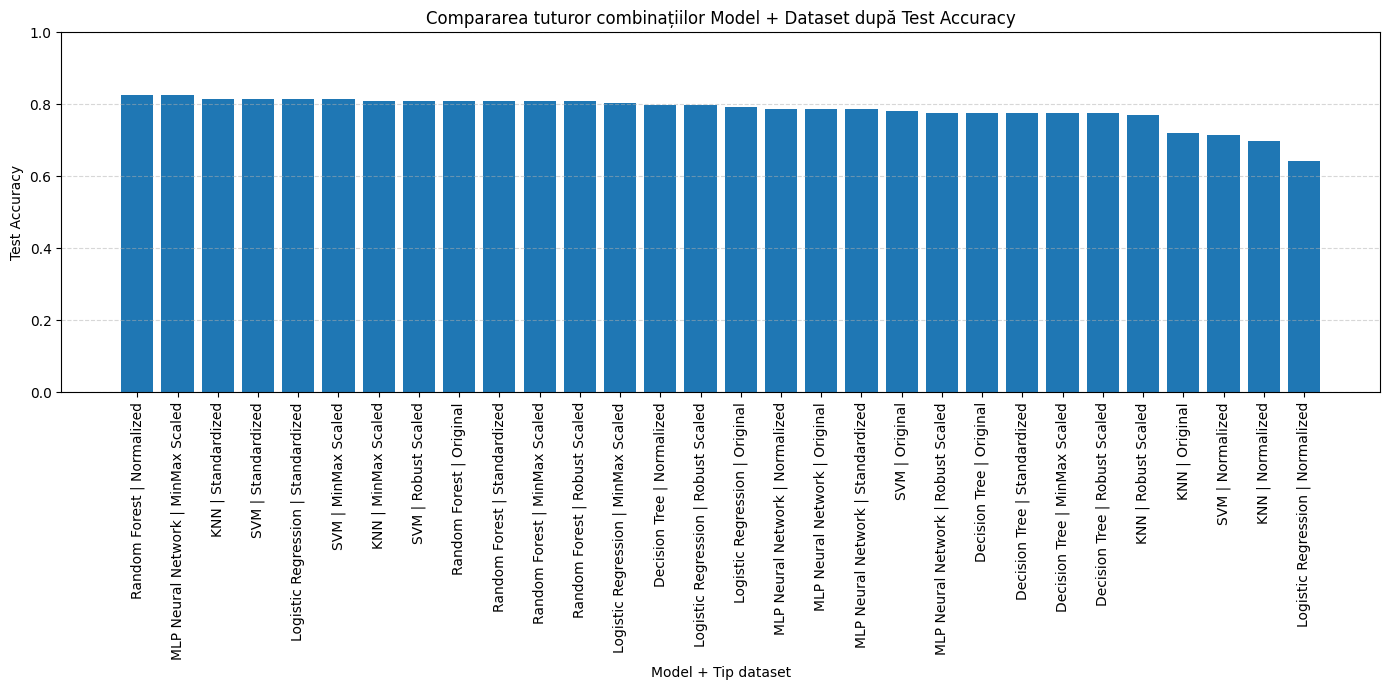

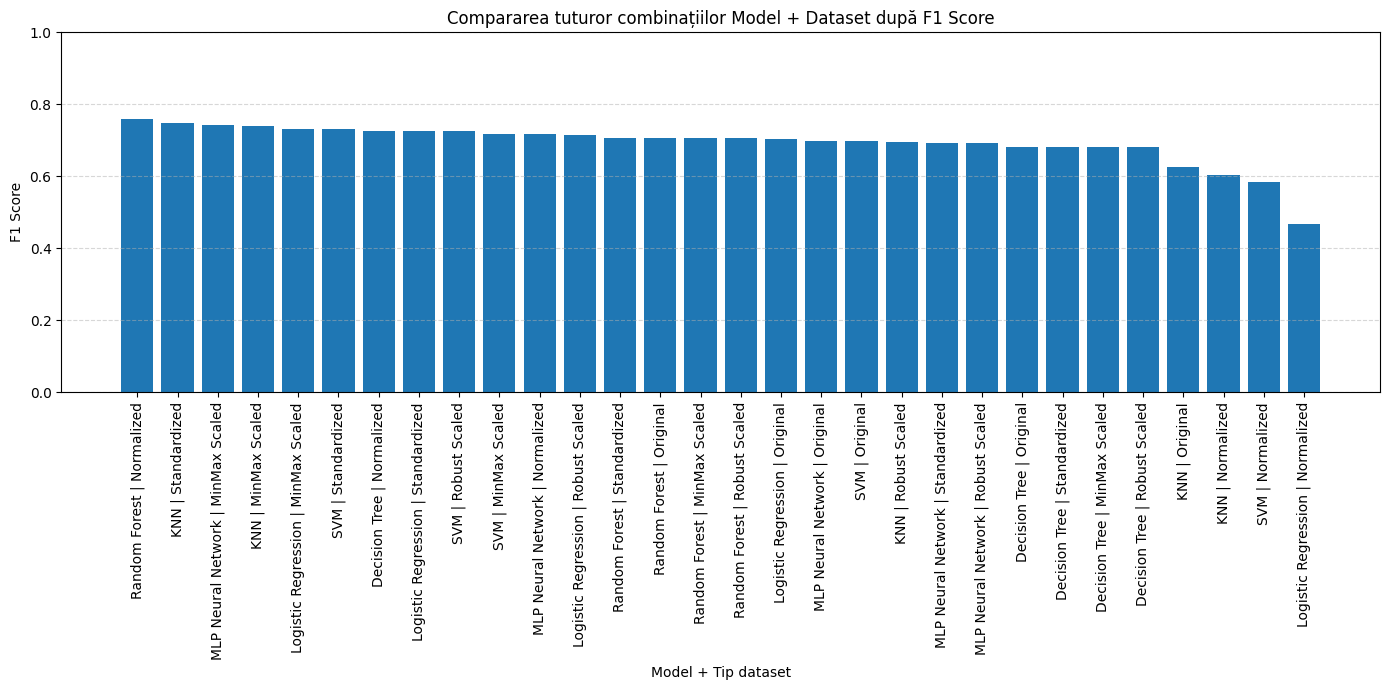

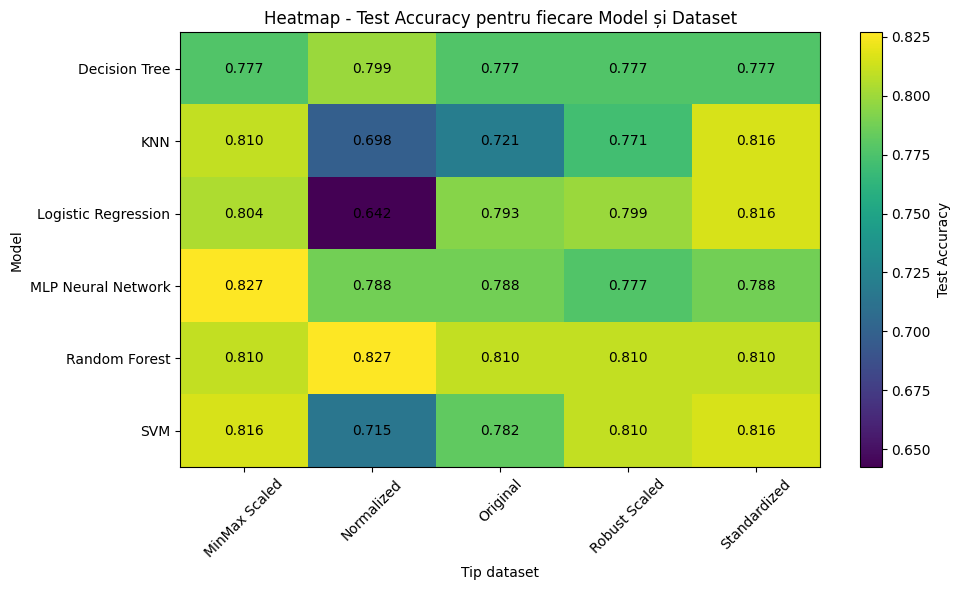

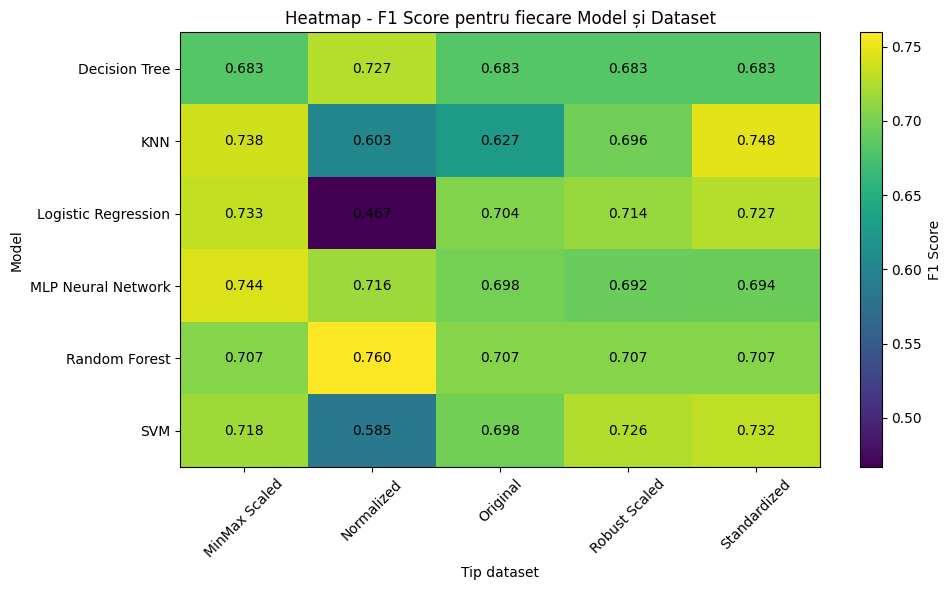

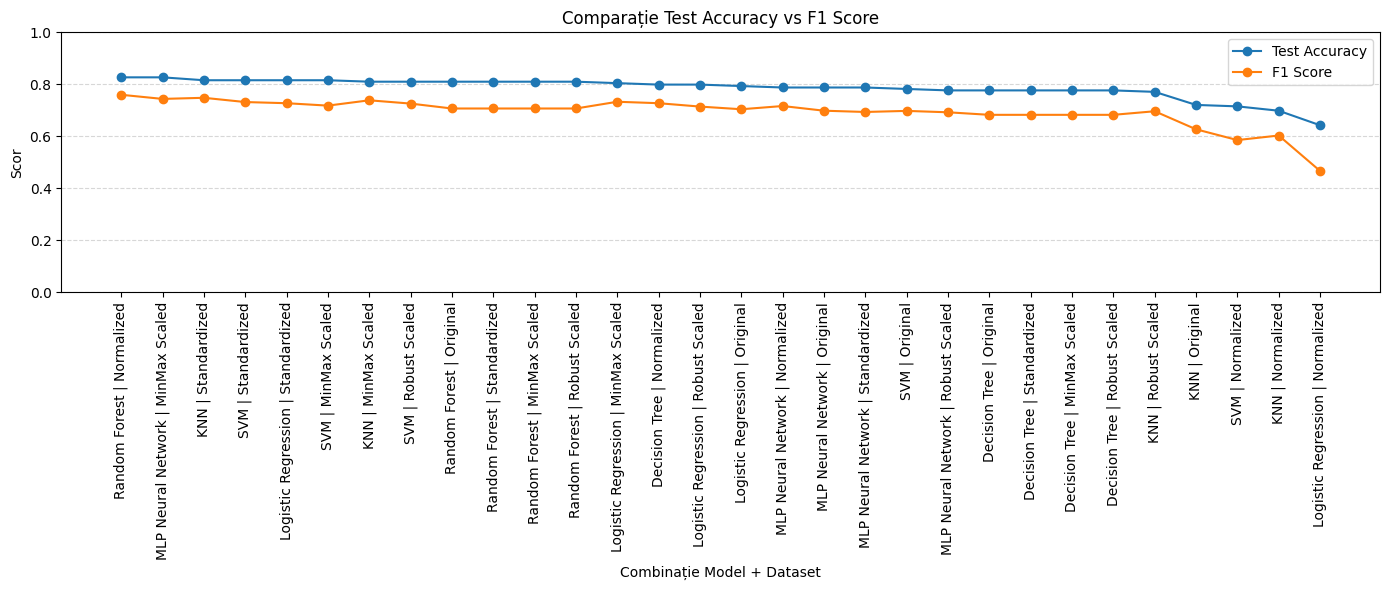

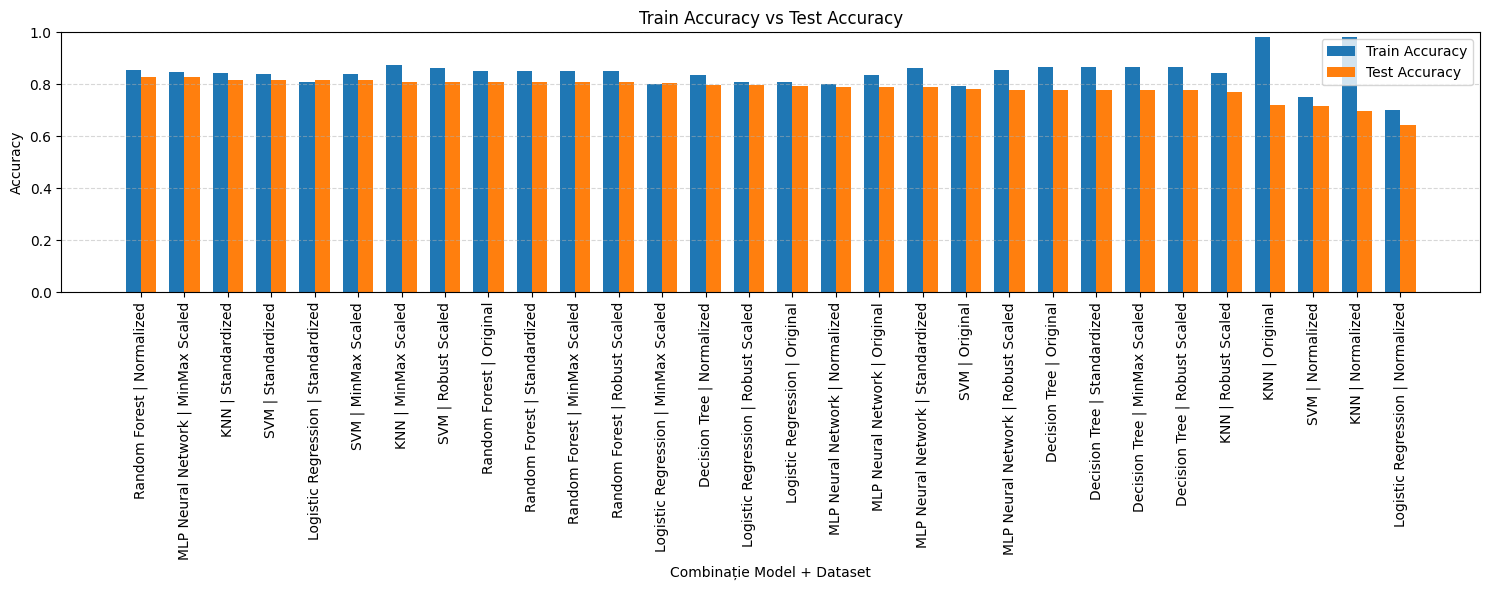

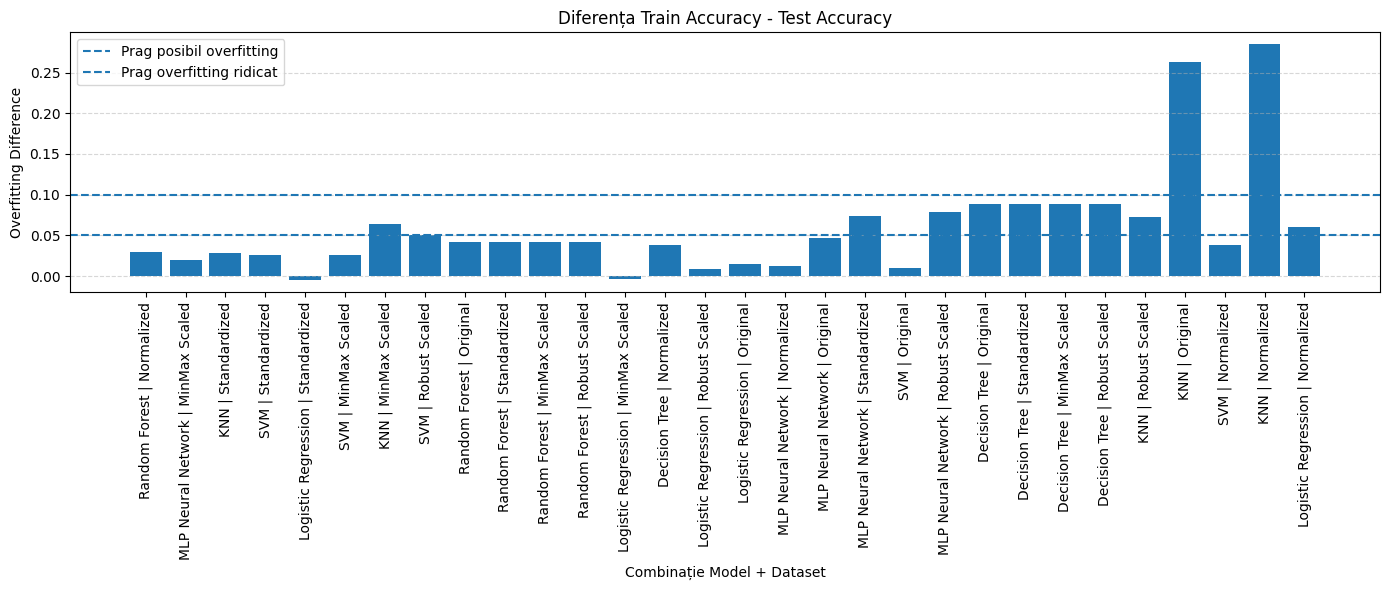

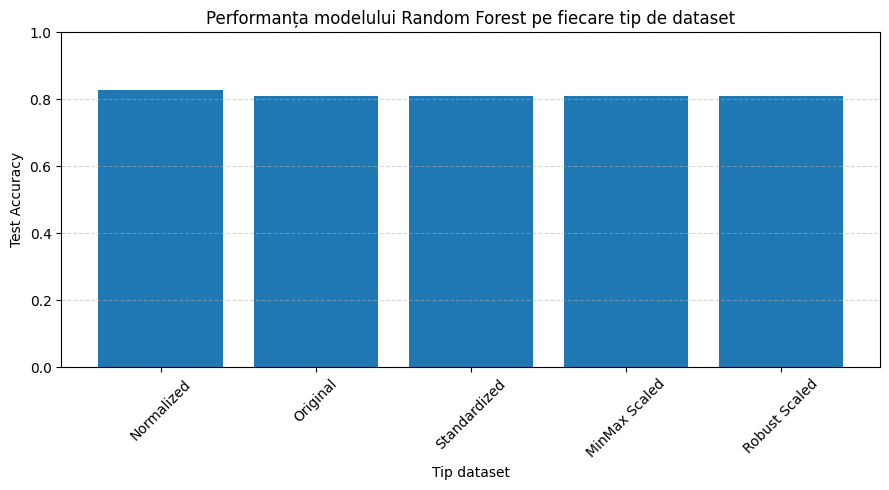

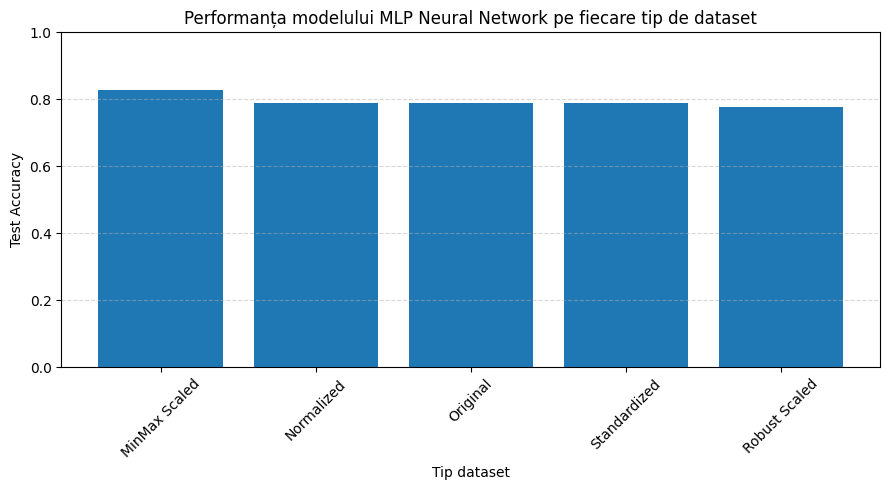

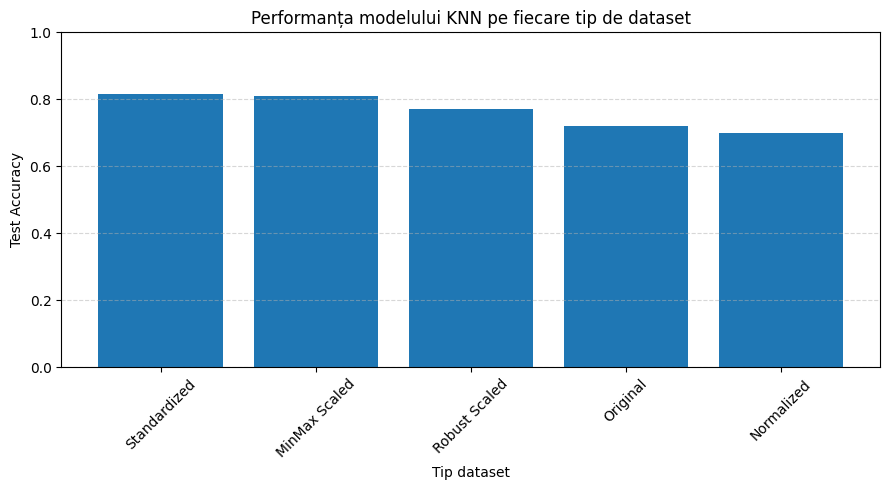

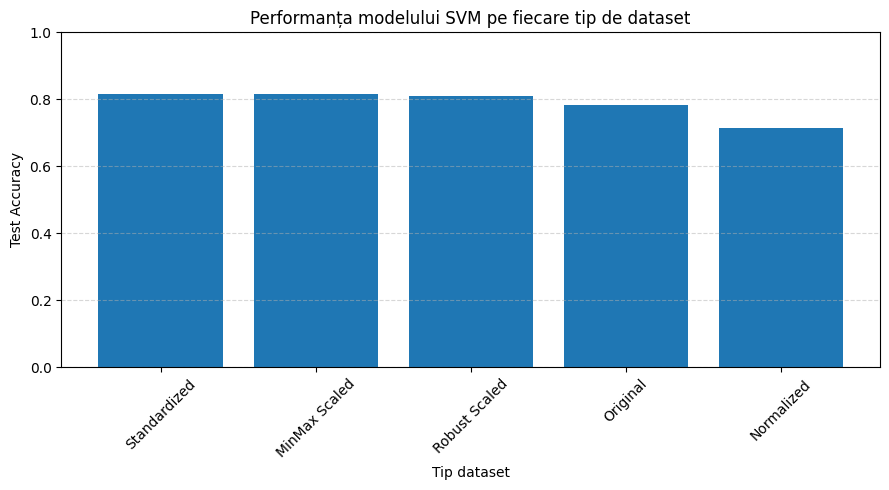

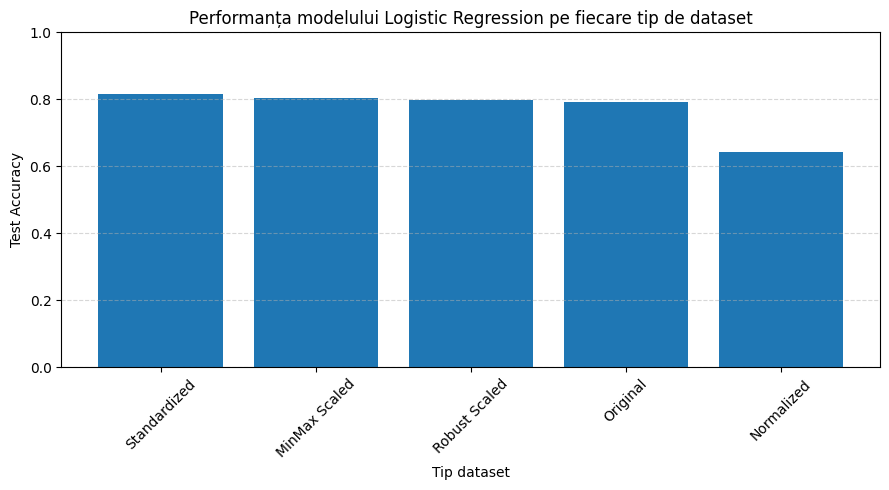

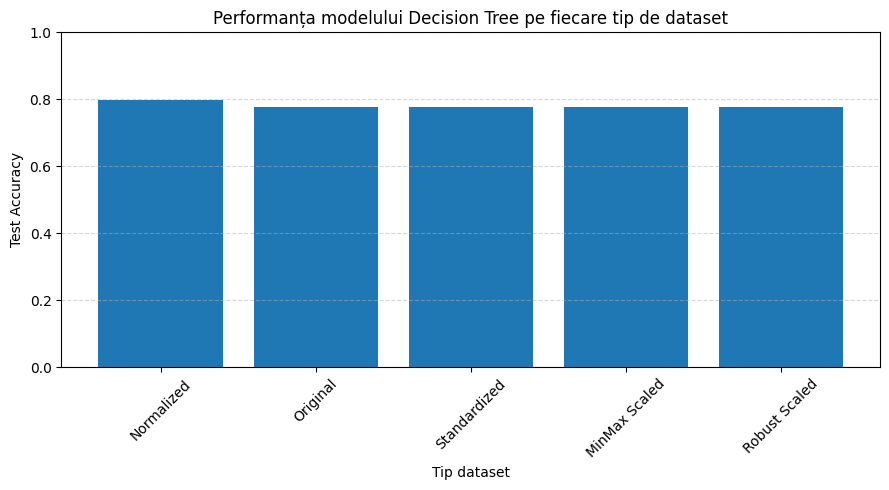

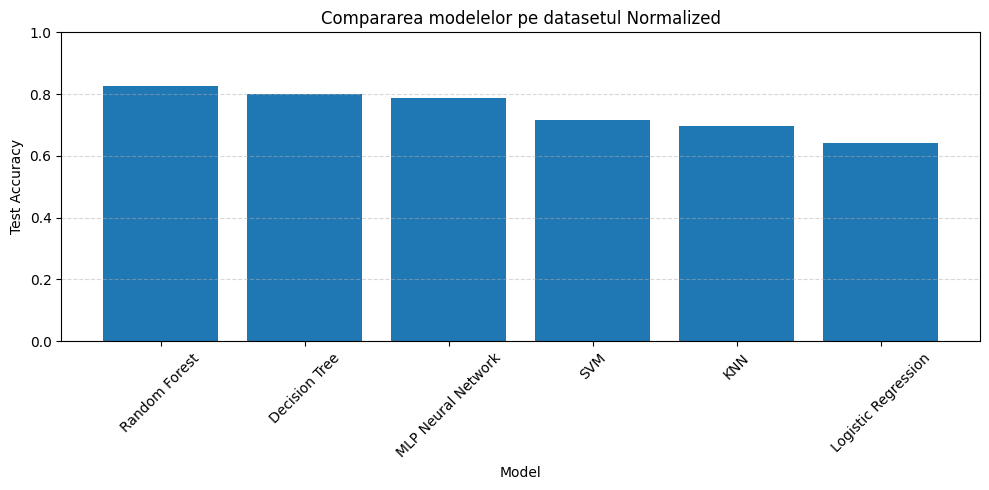

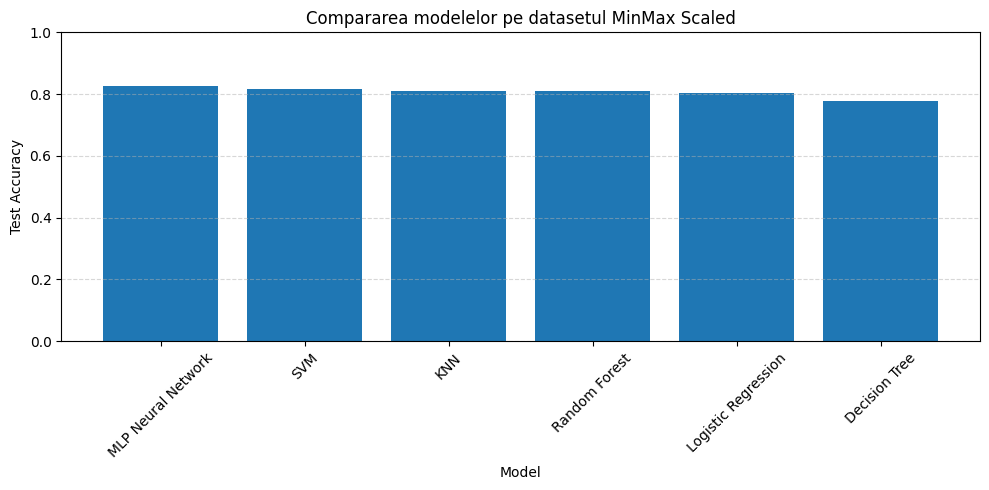

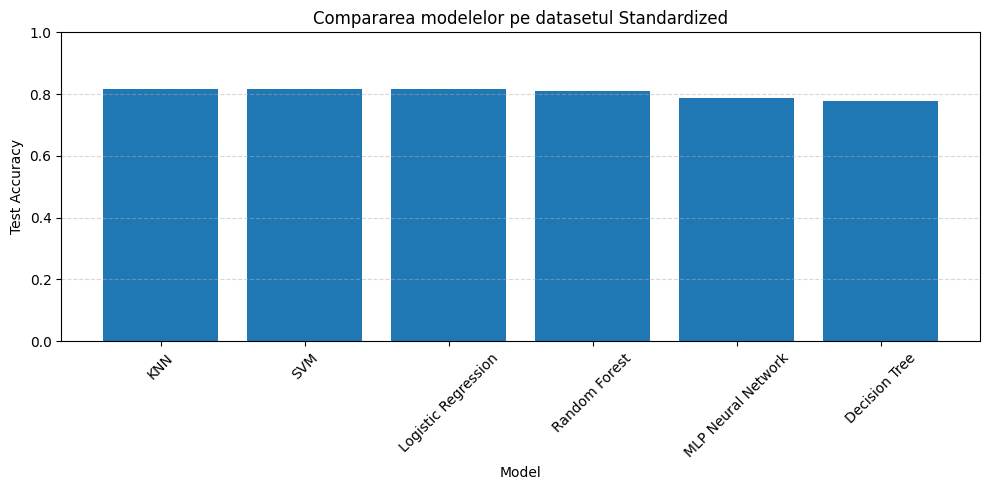

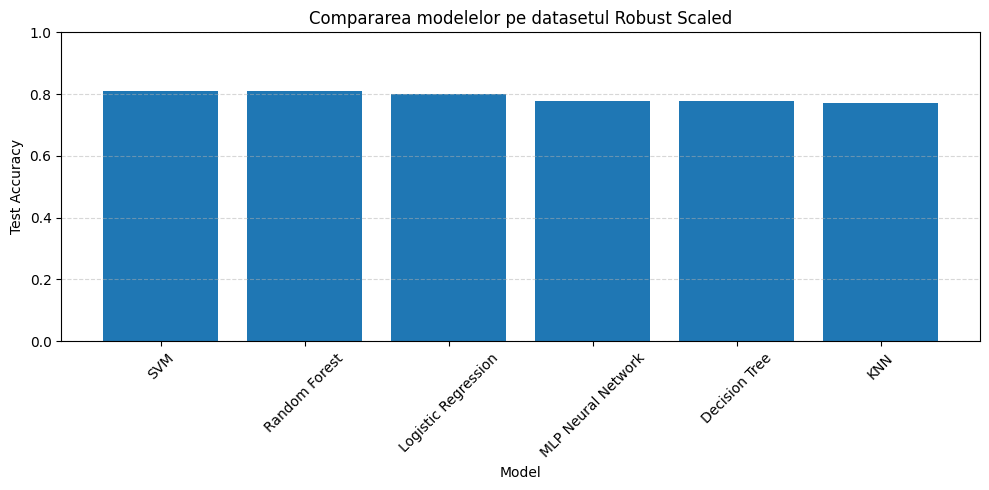

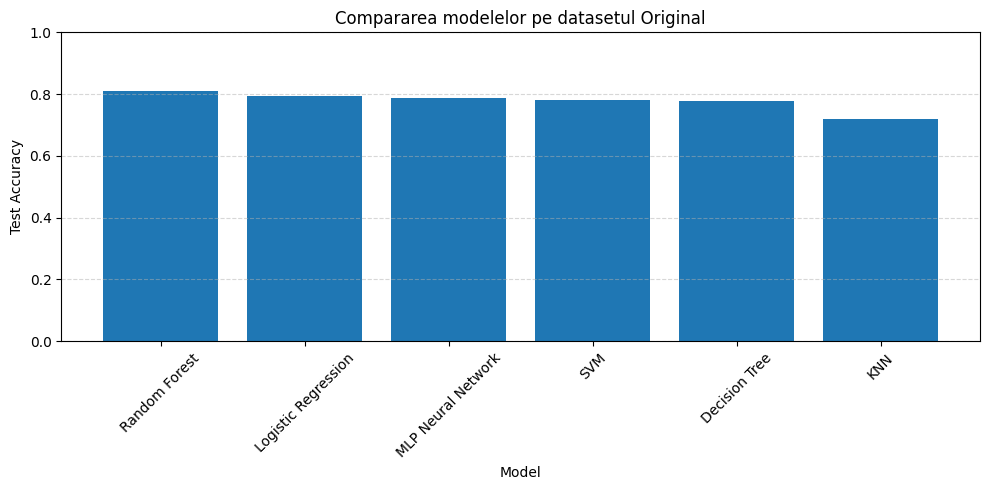

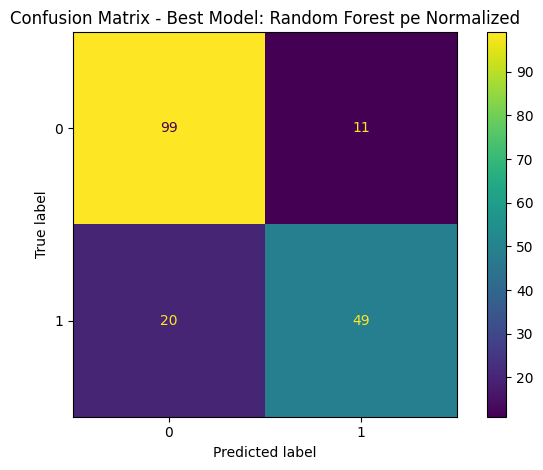


================ INSIGHT-URI AUTOMATE ================

Cel mai bun rezultat general este obținut de modelul Random Forest pe datasetul Normalized.
Accuracy: 0.8268, F1 Score: 0.7597

Cel mai bun dataset pentru fiecare model:
- Decision Tree: cel mai bun pe Normalized cu Accuracy = 0.7989
- KNN: cel mai bun pe Standardized cu Accuracy = 0.8156
- Logistic Regression: cel mai bun pe Standardized cu Accuracy = 0.8156
- MLP Neural Network: cel mai bun pe MinMax Scaled cu Accuracy = 0.8268
- Random Forest: cel mai bun pe Normalized cu Accuracy = 0.8268
- SVM: cel mai bun pe Standardized cu Accuracy = 0.8156

Cel mai bun model pentru fiecare variantă de dataset:
- MinMax Scaled: cel mai bun model este MLP Neural Network cu Accuracy = 0.8268
- Normalized: cel mai bun model este Random Forest cu Accuracy = 0.8268
- Original: cel mai bun model este Random Forest cu Accuracy = 0.8101
- Robust Scaled: cel mai bun model este SVM cu Accuracy = 0.8101
- Standardized: cel mai bun model este KNN cu A

In [10]:
agent4 = VisualizationAgent(
    results=agent3.results,
    best_models=agent3.best_models,
    dataset_versions=dataset_versions
)

agent4.run_all_visualizations()